# 01-1 — Data Preparation & Feature Engineering (Pruned)

Revised feature set based on correlation matrix analysis. Removes redundant features identified
from the Feature Correlation Matrix, keeping a compact orthogonal set.

## Changes from 01_data_preparation.ipynb

| Removed | Reason |
|---------|--------|
| `flatness_insp_50`, `flatness_insp_75` | Highly correlated cluster with `flatness_insp_90`; kept 90 (strongest p-value) |
| `quad_insp` | Correlated with `quad_insp_50`; kept 50 (more targeted: mid-inspiratory scooping) |
| `ie_ratio` | Near-mathematically identical to `insp_duty` (`insp/total` vs `insp/exp`); kept `insp_duty` |
| `auc_insp`, `auc_exp` | Correlated with each other and with timing features; replaced with mean-normalised `auc_insp_mean` |
| `vol_ratio` | Non-significant (p=0.19); removed |
| `insp_cv` | Non-significant (p=0.09); removed |

**Final feature set: 10 features** (down from 22)

## Data layout expected
```
/data/
  <patient_id>/
    *breaths*.csv          — breath labels (start_s, end_s, label)
    *signals*.parquet      — raw signals at 100 Hz
    *signals_meta*.json    — metadata (fs_target, columns, etc.)
    *breaths*.xlsx         — optional Excel version of labels
```

## Output
- `features_clean_v2.csv` — one row per breath, 10 amplitude-independent features + metadata

## Labels used
- `FL` → target = 1
- `NFL` → target = 0
- `Apnea`, `Remove`, `PFL` → excluded

## 1. Setup & Imports

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal as scipy_signal
from scipy.stats import skew, kurtosis, mannwhitneyu

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

# ── Configuration ─────────────────────────────────────────────────────────────
DATA_PATH   = Path('./data')               # root: one subfolder per patient
OUTPUT_CSV  = Path('features_clean_v2.csv')
FS          = 100.0                        # target sampling rate (Hz)
LABELS_USE  = {'FL': 1, 'NFL': 0}         # only these labels are kept
MIN_SAMPLES = 20                           # minimum samples per breath window

print(f'Data root : {DATA_PATH}')
print(f'Output    : {OUTPUT_CSV}')
print(f'Labels    : {LABELS_USE}')

Data root : data
Output    : features_clean_v2.csv
Labels    : {'FL': 1, 'NFL': 0}


## 2. Load Data — All Patients

In [2]:
def load_patient(patient_dir: Path):
    """
    Load breath labels and signal parquet for one patient directory.
    Returns (breaths_df, signals_df, patient_id) or None on failure.
    """
    pid = patient_dir.name

    # ── Breath labels: prefer CSV, fall back to XLSX ──────────────────────────
    csv_files  = list(patient_dir.glob('*breaths*.csv'))
    xlsx_files = list(patient_dir.glob('*breaths*.xlsx'))

    if csv_files:
        breaths = pd.read_csv(csv_files[0])
    elif xlsx_files:
        breaths = pd.read_excel(xlsx_files[0])
    else:
        print(f'  [SKIP] {pid}: no breath label file found')
        return None

    breaths.columns = [c.lower().strip() for c in breaths.columns]

    rename_map = {'start (s)': 'start_s', 'end (s)': 'end_s', 'label': 'label'}
    breaths = breaths.rename(columns=rename_map)
    for col in ('start_s', 'end_s', 'label'):
        if col not in breaths.columns:
            print(f'  [SKIP] {pid}: missing column "{col}" in breath file')
            return None

    breaths['participant'] = pid

    # ── Signal parquet ────────────────────────────────────────────────────────
    parquet_files = list(patient_dir.glob('*signals*.parquet'))
    if not parquet_files:
        print(f'  [SKIP] {pid}: no parquet signal file found')
        return None

    signals = pd.read_parquet(parquet_files[0])
    if 'time_s' not in signals.columns:
        print(f'  [SKIP] {pid}: parquet missing time_s column')
        return None

    return breaths, signals, pid


# ── Iterate all patient directories ──────────────────────────────────────────
patient_dirs = sorted([d for d in DATA_PATH.iterdir() if d.is_dir()])
print(f'Found {len(patient_dirs)} patient directories\n')

all_records = []   # list of (breaths_df, signals_df, pid)
skipped = []

for p_dir in patient_dirs:
    result = load_patient(p_dir)
    if result is None:
        skipped.append(p_dir.name)
    else:
        all_records.append(result)

print(f'Loaded  : {len(all_records)} patients')
print(f'Skipped : {len(skipped)} — {skipped}')

Found 87 patient directories

  [SKIP] KG_2023-09: no breath label file found
  [SKIP] MB_2023-10: no breath label file found
  [SKIP] RB_2021-08: no breath label file found
Loaded  : 84 patients
Skipped : 3 — ['KG_2023-09', 'MB_2023-10', 'RB_2021-08']


## 3. Feature Extraction Functions

All features are:
1. **Amplitude-independent** — normalised by phase peak (PIF / PEF)
2. **Phase-separated** — computed on inspiratory (flow > 0) or expiratory (flow < 0) independently
3. **Grounded in Mann et al.** for the core shape features
4. **Non-redundant** — collinear features removed based on correlation matrix analysis

### Retained features (10 total)

| Group | Feature | Description |
|-------|---------|-------------|
| Scooping | `quad_insp_50` | Mid-inspiratory quadratic deviation (QuadI50, Mann et al.) |
| Scooping | `quad_exp` | Expiratory quadratic deviation (QuadE, Mann et al.) |
| Scooping | `area_under_peaks_insp` | AreaUnderPeaksI (Mann et al.) |
| Flutter | `power_5to12_insp` | Inspiratory 5–12 Hz power ratio (Mann et al.) |
| Flutter | `power_5to12_exp` | Expiratory 5–12 Hz power ratio (Mann et al.) |
| Flatness | `flatness_insp_90` | Fraction of inspiration ≥ 90% of PIF |
| Asymmetry | `insp_peak_position` | Normalised position of inspiratory peak |
| Timing | `insp_duty` | Fraction of breath spent in inspiration |
| Timing | `breath_duration` | Total breath duration (s) |
| Variability | `exp_cv` | Expiratory coefficient of variation |
| Variability | `insp_skew` | Inspiratory skewness |
| Variability | `insp_kurt` | Inspiratory kurtosis |
| Variability | `exp_skew` | Expiratory skewness |
| Shape fill | `auc_insp_mean` | Mean of normalised inspiratory curve (shape fill, amplitude-independent) |

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Phase-level primitives
# ─────────────────────────────────────────────────────────────────────────────

def split_phases(flow: np.ndarray):
    """
    Split breath into inspiratory (flow > 0) and expiratory (flow < 0) samples.
    Returns (insp, exp_positive) where exp_positive = abs(expiratory samples).
    """
    insp = flow[flow > 0]
    exp  = -flow[flow < 0]   # flip to positive for symmetric feature computation
    return insp, exp


def quadratic_deviation(phase_norm: np.ndarray) -> float:
    """
    Mean absolute deviation of normalised phase from a matched parabola.
    Implements QuadI (full) and QuadE from Mann et al.
    Parabola: f(t) = 4t(1-t), peaks at 1.0 at t=0.5.
    phase_norm should be normalised so its peak ≈ 1.0.
    """
    n = len(phase_norm)
    if n < 4:
        return np.nan
    t = np.linspace(0, 1, n)
    parabola = 4 * t * (1 - t)
    return float(np.mean(np.abs(phase_norm - parabola)))


def quadratic_deviation_mid50(insp_norm: np.ndarray) -> float:
    """
    QuadI50: quadratic deviation restricted to the 25th–75th percentile
    of inspiratory time. Captures mid-inspiratory scooping specifically.
    Preferred over full quad_insp: more targeted, less correlated with flatness.
    """
    n = len(insp_norm)
    if n < 8:
        return np.nan
    q25, q75 = int(0.25 * n), int(0.75 * n)
    mid = insp_norm[q25:q75]
    t = np.linspace(0, 1, len(mid))
    parabola = 4 * t * (1 - t)
    return float(np.mean(np.abs(mid - parabola)))


def band_power_ratio(phase: np.ndarray, fs: float,
                     fmin: float = 5.0, fmax: float = 12.0) -> float:
    """
    Power5to12I / Power5to12E from Mann et al.
    Fraction of total spectral power in the 5–12 Hz band (flutter range).
    Amplitude-independent because it is a ratio.
    """
    if len(phase) < 20:
        return np.nan
    nperseg = min(32, len(phase) // 2)
    freqs, pxx = scipy_signal.welch(phase, fs=fs, nperseg=nperseg)
    total = np.sum(pxx)
    if total == 0:
        return np.nan
    band_mask = (freqs >= fmin) & (freqs <= fmax)
    return float(np.sum(pxx[band_mask]) / total)


def area_under_peaks(insp: np.ndarray) -> float:
    """
    AreaUnderPeaksI from Mann et al.
    Mean absolute deviation between the inspiratory flow signal and a line
    connecting its local peaks, normalised by PIF.
    Captures irregular scooping not captured by global parabolic fit.
    """
    if len(insp) < 10:
        return np.nan
    peaks, _ = scipy_signal.find_peaks(insp, distance=max(3, len(insp) // 10))
    if len(peaks) < 2:
        return np.nan
    peak_line = np.interp(np.arange(len(insp)), peaks, insp[peaks])
    pif = np.max(insp)
    return float(np.mean(np.abs(insp - peak_line)) / (pif + 1e-9))


def flatness(phase_norm: np.ndarray, threshold: float) -> float:
    """Fraction of phase samples at or above `threshold` of the peak."""
    return float(np.sum(phase_norm >= threshold) / len(phase_norm))


print('Feature primitives defined.')

Feature primitives defined.


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Main feature extraction — one breath at a time
# ─────────────────────────────────────────────────────────────────────────────

def extract_features(flow: np.ndarray, duration_s: float, fs: float = 100.0) -> dict:
    """
    Extract 14 amplitude-independent, phase-separated features from a
    single breath's flow signal.

    Pruned from 22-feature set based on correlation matrix analysis:
    - flatness_insp_50, flatness_insp_75 removed (cluster with flatness_insp_90)
    - quad_insp removed (cluster with quad_insp_50; kept the more targeted 50)
    - ie_ratio removed (near-identical to insp_duty)
    - auc_insp, auc_exp removed; replaced with mean-normalised auc_insp_mean
    - vol_ratio removed (p=0.19, non-significant)
    - insp_cv removed (p=0.09, non-significant)
    - pif_pef_ratio removed (correlated with exp_cv and insp_skew cluster)

    Feature groups
    --------------
    Scooping (Mann)   : quad_insp_50, quad_exp, area_under_peaks_insp
    Flutter (Mann)    : power_5to12_insp, power_5to12_exp
    Flatness          : flatness_insp_90
    Asymmetry         : insp_peak_position
    Phase timing      : insp_duty, breath_duration
    Shape variability : exp_cv, insp_skew, insp_kurt, exp_skew
    Shape fill        : auc_insp_mean
    """
    if len(flow) < MIN_SAMPLES:
        return None

    insp, exp = split_phases(flow)
    if len(insp) < 5 or len(exp) < 5:
        return None

    pif = float(np.max(insp))
    pef = float(np.max(exp))

    # Normalise each phase by its own peak
    insp_norm = insp / (pif + 1e-9)
    exp_norm  = exp  / (pef + 1e-9)

    f = {}

    # ── Scooping (Mann et al.) ────────────────────────────────────────────────
    # quad_insp dropped: highly correlated with quad_insp_50 in correlation matrix
    f['quad_insp_50']          = quadratic_deviation_mid50(insp_norm)
    f['quad_exp']              = quadratic_deviation(exp_norm)
    f['area_under_peaks_insp'] = area_under_peaks(insp)

    # ── Flutter: band-limited spectral power 5–12 Hz (Mann et al.) ────────────
    f['power_5to12_insp'] = band_power_ratio(insp, fs)
    f['power_5to12_exp']  = band_power_ratio(exp,  fs)

    # ── Flatness (inspiratory phase only) ─────────────────────────────────────
    # flatness_insp_50 and flatness_insp_75 dropped: highly correlated cluster.
    # flatness_insp_90 kept: strongest p-value of the three.
    f['flatness_insp_90'] = flatness(insp_norm, 0.90)

    # ── Asymmetry ─────────────────────────────────────────────────────────────
    # Where within the inspiratory phase does the peak occur? (0=early, 1=late)
    f['insp_peak_position'] = float(np.argmax(insp) / len(insp))
    # pif_pef_ratio dropped: correlated with exp_cv / insp_skew cluster

    # ── Phase timing ──────────────────────────────────────────────────────────
    # ie_ratio dropped: near-mathematically identical to insp_duty
    # (insp_duty = insp/total, ie_ratio = insp/exp — same information)
    n_total = len(flow)
    f['insp_duty']       = len(insp) / n_total
    f['breath_duration'] = float(duration_s)

    # ── Shape variability (per-phase, normalised) ─────────────────────────────
    # insp_cv dropped: non-significant (p=0.09)
    f['exp_cv']    = float(np.std(exp_norm) / (np.mean(exp_norm) + 1e-9))
    f['insp_skew'] = float(skew(insp_norm))
    f['exp_skew']  = float(skew(exp_norm))
    f['insp_kurt'] = float(kurtosis(insp_norm))

    # ── Shape fill (amplitude-independent, decorrelated from timing) ──────────
    # Replaces auc_insp + auc_exp (which were correlated with each other and
    # with phase duration). Mean of the normalised curve = fill fraction 0→1,
    # where 1 = perfect rectangle, ~0.67 = ideal parabola.
    # vol_ratio dropped: non-significant (p=0.19)
    f['auc_insp_mean'] = float(np.mean(insp_norm))

    return f


# Sanity check: list all feature names
FEATURE_NAMES = [
    'quad_insp_50', 'area_under_peaks_insp',
    'power_5to12_insp', 'power_5to12_exp',
    'flatness_insp_90',
    'insp_peak_position',
    'insp_duty', 'breath_duration',
    'exp_cv', 'insp_skew', 'insp_kurt',
]
print(f'Feature set: {len(FEATURE_NAMES)} features (pruned from 22)')
for i, fn in enumerate(FEATURE_NAMES, 1):
    print(f'  {i:2d}. {fn}')

Feature set: 11 features (pruned from 22)
   1. quad_insp_50
   2. area_under_peaks_insp
   3. power_5to12_insp
   4. power_5to12_exp
   5. flatness_insp_90
   6. insp_peak_position
   7. insp_duty
   8. breath_duration
   9. exp_cv
  10. insp_skew
  11. insp_kurt


## 4. Process All Patients

In [18]:
rows = []          # one dict per breath
stats = {          # summary counters
    'total_breaths': 0,
    'kept': 0,
    'excluded_label': 0,
    'excluded_signal': 0,
    'excluded_phase': 0,
}

for breaths_df, signals_df, pid in all_records:

    for _, row in breaths_df.iterrows():
        stats['total_breaths'] += 1
        label = str(row['label']).strip()

        # ── Filter to FL / NFL only ───────────────────────────────────────────
        if label not in LABELS_USE:
            stats['excluded_label'] += 1
            continue

        start_s = float(row['start_s'])
        end_s   = float(row['end_s'])

        # ── Extract signal window ─────────────────────────────────────────────
        window = signals_df[
            (signals_df['time_s'] >= start_s) &
            (signals_df['time_s'] <  end_s)
        ]

        if 'sig_flow' not in window.columns or len(window) < MIN_SAMPLES:
            stats['excluded_signal'] += 1
            continue

        flow = window['sig_flow'].values.astype(np.float64)
        duration = end_s - start_s

        # ── Extract features ──────────────────────────────────────────────────
        feats = extract_features(flow, duration_s=duration, fs=FS)
        if feats is None:
            stats['excluded_phase'] += 1
            continue

        feats['participant']   = pid
        feats['breath_number'] = row.get('breath #', row.get('breath_number', np.nan))
        feats['start_s']       = start_s
        feats['end_s']         = end_s
        feats['label']         = label
        feats['target']        = LABELS_USE[label]
        rows.append(feats)
        stats['kept'] += 1


features_df = pd.DataFrame(rows)

print('=== Processing Summary ===')
for k, v in stats.items():
    print(f'  {k:<25}: {v}')
print(f'\nDataset shape : {features_df.shape}')
print(f'FL  (target=1): {(features_df["target"]==1).sum()}')
print(f'NFL (target=0): {(features_df["target"]==0).sum()}')
print(f'Participants  : {features_df["participant"].nunique()}')
print(f'NaN count     : {features_df[FEATURE_NAMES].isna().sum().sum()}')

=== Processing Summary ===
  total_breaths            : 9277
  kept                     : 7006
  excluded_label           : 2270
  excluded_signal          : 0
  excluded_phase           : 1

Dataset shape : (7006, 20)
FL  (target=1): 3637
NFL (target=0): 3369
Participants  : 84
NaN count     : 15


## 5. Validation Checks

In [19]:
# ── 5a. Check amplitude independence ─────────────────────────────────────────
# Scale a single breath by 2x and verify features are unchanged

sample_row = features_df.iloc[0]
sample_pid  = sample_row['participant']
_, sample_signals, _ = next(r for r in all_records if r[2] == sample_pid)

window = sample_signals[
    (sample_signals['time_s'] >= sample_row['start_s']) &
    (sample_signals['time_s'] <  sample_row['end_s'])
]
flow_orig = window['sig_flow'].values.astype(float)
flow_2x   = flow_orig * 2.0

f_orig = extract_features(flow_orig, sample_row['breath_duration'])
f_2x   = extract_features(flow_2x,   sample_row['breath_duration'])

print('=== Amplitude Independence Check (2x scaling) ===')
print(f'{"Feature":<30} {"Original":>12} {"2x Scaled":>12} {"Max diff":>12}')
print('-' * 68)
for feat in FEATURE_NAMES:
    v1   = f_orig.get(feat, np.nan)
    v2   = f_2x.get(feat, np.nan)
    diff = abs(v1 - v2) if (v1 is not None and v2 is not None) else np.nan
    flag = '  *** NOT INDEPENDENT ***' if (not np.isnan(diff) and diff > 1e-6) else ''
    print(f'{feat:<30} {v1:>12.5f} {v2:>12.5f} {diff:>12.2e}{flag}')

=== Amplitude Independence Check (2x scaling) ===
Feature                            Original    2x Scaled     Max diff
--------------------------------------------------------------------
quad_insp_50                        0.23774      0.23774     2.18e-12
area_under_peaks_insp               0.08469      0.08469     1.86e-12
power_5to12_insp                    0.19170      0.19170     0.00e+00
power_5to12_exp                     0.18206      0.18206     0.00e+00
flatness_insp_90                    0.07299      0.07299     0.00e+00
insp_peak_position                  0.34307      0.34307     0.00e+00
insp_duty                           0.48754      0.48754     0.00e+00
breath_duration                     2.82000      2.82000     0.00e+00
exp_cv                              0.45595      0.45595     5.55e-17
insp_skew                          -1.24771     -1.24771     1.78e-15
insp_kurt                           0.78324      0.78324     2.66e-15


In [20]:
# ── 5b. Per-feature discriminative power: Mann-Whitney U ─────────────────────

fl_df  = features_df[features_df['target'] == 1]
nfl_df = features_df[features_df['target'] == 0]

mw_results = []
for feat in FEATURE_NAMES:
    fl_v  = fl_df[feat].dropna()
    nfl_v = nfl_df[feat].dropna()
    if len(fl_v) < 5 or len(nfl_v) < 5:
        continue
    _, p = mannwhitneyu(fl_v, nfl_v, alternative='two-sided')
    mw_results.append({
        'feature' : feat,
        'p_value' : p,
        'fl_mean' : fl_v.mean(),
        'nfl_mean': nfl_v.mean(),
        'fl_med'  : fl_v.median(),
        'nfl_med' : nfl_v.median(),
    })

mw_df = pd.DataFrame(mw_results).sort_values('p_value').reset_index(drop=True)
mw_df['significant'] = mw_df['p_value'] < 0.05

print('=== Mann-Whitney U: FL vs NFL (sorted by p-value) ===')
print(mw_df[['feature','p_value','fl_mean','nfl_mean','significant']].to_string(index=False))
print(f'\nSignificant features (p<0.05): {mw_df["significant"].sum()} / {len(mw_df)}')

=== Mann-Whitney U: FL vs NFL (sorted by p-value) ===
              feature       p_value   fl_mean  nfl_mean  significant
area_under_peaks_insp 1.570309e-257  0.097829  0.063211         True
     power_5to12_insp 1.639616e-252  0.172336  0.114309         True
     flatness_insp_90 5.776318e-244  0.142844  0.232395         True
      power_5to12_exp 1.452605e-234  0.167756  0.114459         True
         quad_insp_50 6.505290e-147  0.329239  0.272862         True
               exp_cv 1.617263e-143  0.680672  0.848646         True
            insp_kurt 3.259009e-121  0.170331 -0.580170         True
            insp_skew  2.601918e-87 -0.172093 -0.596573         True
            insp_duty  4.113635e-42  0.464207  0.432049         True
   insp_peak_position  3.820405e-33  0.401899  0.455038         True
      breath_duration  3.750491e-18  3.603827  3.415660         True

Significant features (p<0.05): 11 / 11


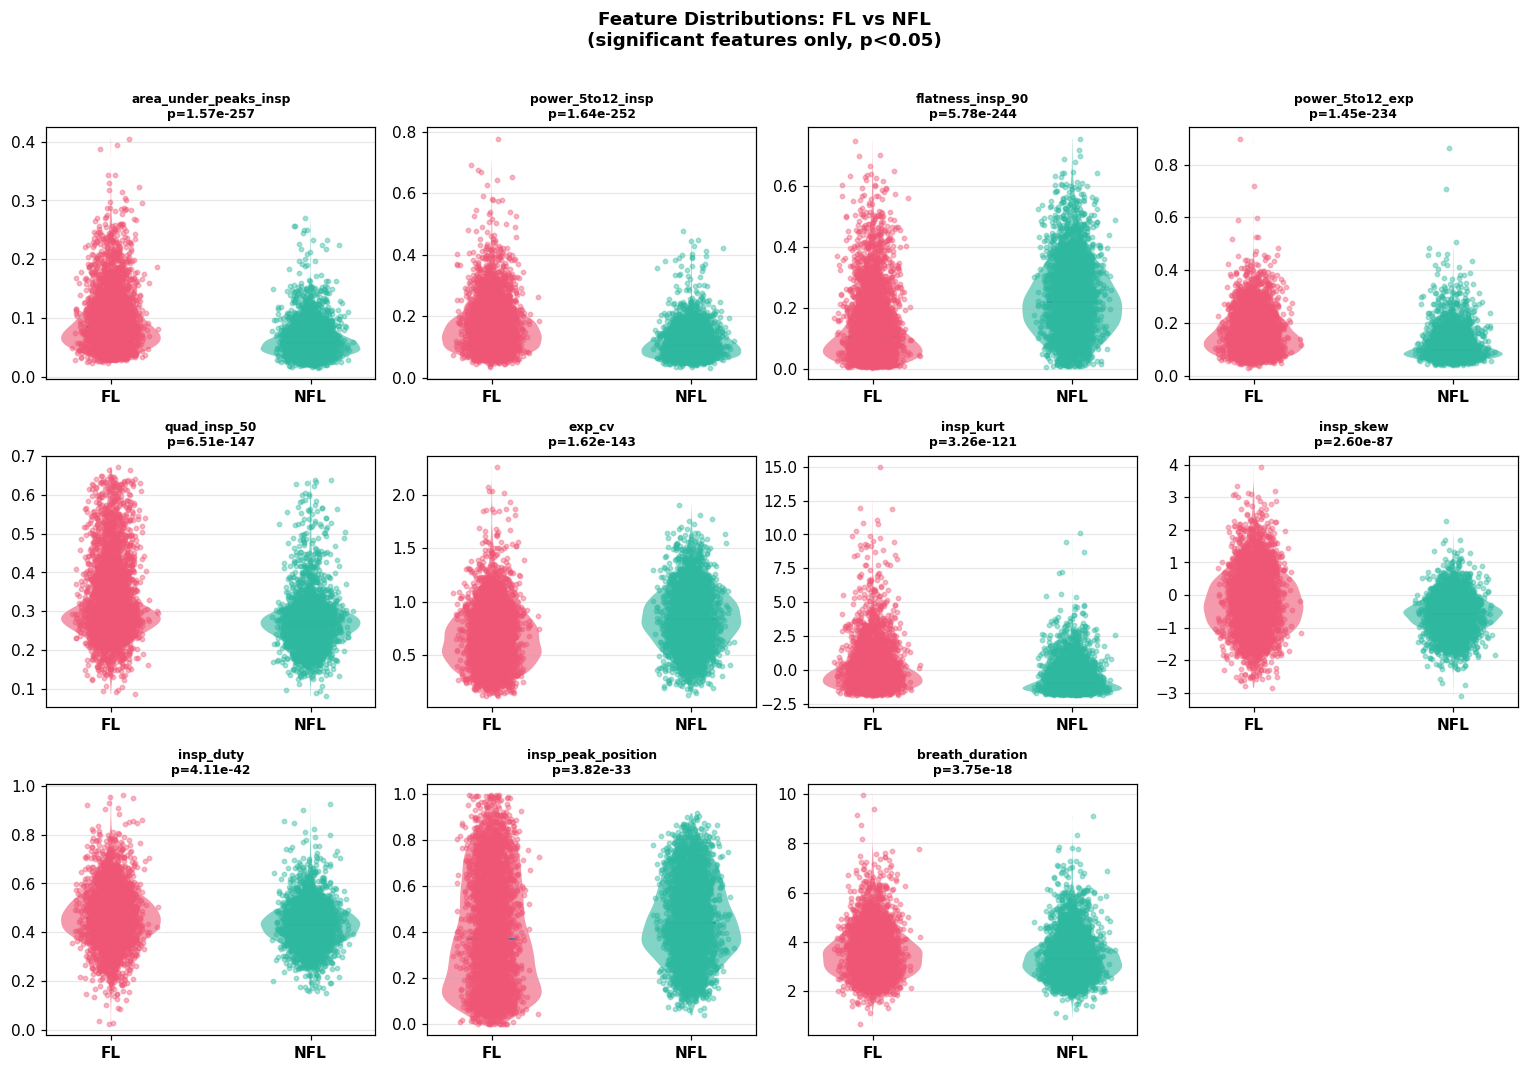

Saved: feature_distributions_v2.png


In [21]:
# ── 5c. Feature distributions: violin plots FL vs NFL ────────────────────────

sig_feats = mw_df[mw_df['significant']]['feature'].tolist()
n_plot    = min(len(sig_feats), 12)

if n_plot == 0:
    print('No significant features to plot (check data / label distribution).')
else:
    ncols = 4
    nrows = int(np.ceil(n_plot / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.2))
    axes = axes.flatten()

    for i, feat in enumerate(sig_feats[:n_plot]):
        ax = axes[i]
        fl_v  = fl_df[feat].dropna().values
        nfl_v = nfl_df[feat].dropna().values
        vp = ax.violinplot([fl_v, nfl_v], positions=[0, 1],
                            showmedians=True, showextrema=False)
        vp['bodies'][0].set_facecolor('#ef5675')
        vp['bodies'][1].set_facecolor('#2eb8a0')
        for b in vp['bodies']:
            b.set_alpha(0.6)
        np.random.seed(42)
        ax.scatter(np.random.normal(0, 0.06, len(fl_v)),  fl_v,
                   color='#ef5675', alpha=0.4, s=8, zorder=3)
        ax.scatter(np.random.normal(1, 0.06, len(nfl_v)), nfl_v,
                   color='#2eb8a0', alpha=0.4, s=8, zorder=3)
        p_val = mw_df[mw_df['feature'] == feat]['p_value'].values[0]
        ax.set_title(f'{feat}\np={p_val:.2e}', fontsize=8, fontweight='bold')
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['FL', 'NFL'], fontweight='bold')
        ax.grid(axis='y', alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Feature Distributions: FL vs NFL\n(significant features only, p<0.05)',
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('feature_distributions_v2.png', dpi=110, bbox_inches='tight')
    plt.show()
    print('Saved: feature_distributions_v2.png')

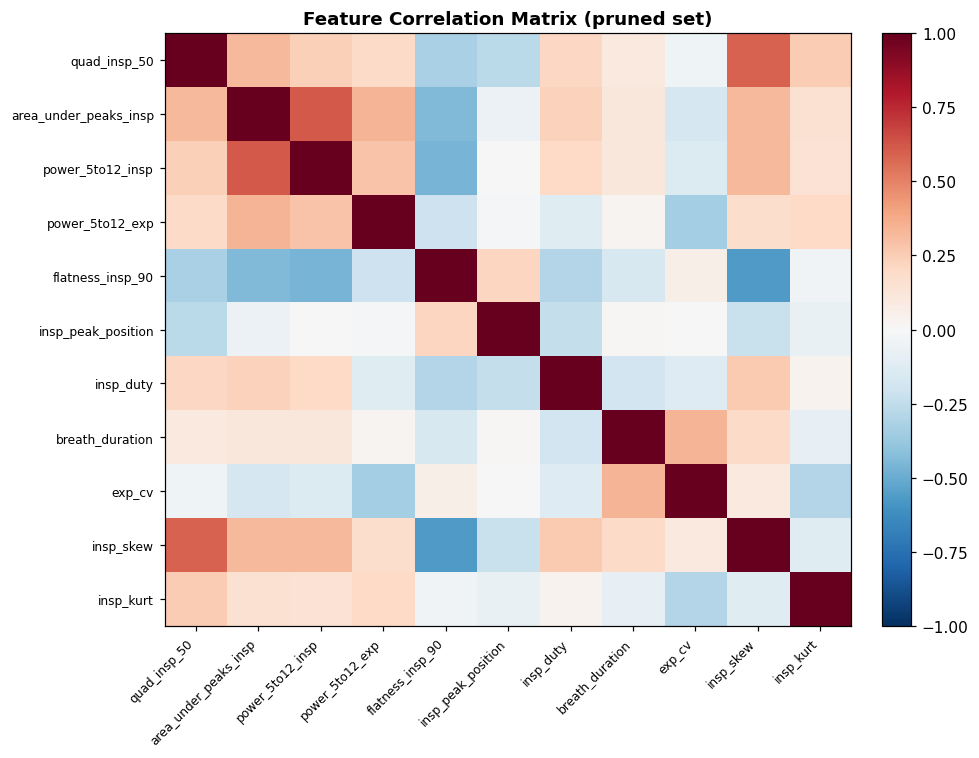

Saved: feature_correlation_v2.png

⚠  Remaining high correlations (|r| ≥ 0.6):
  area_under_peaks_insp     × power_5to12_insp           r=+0.616


In [22]:
# ── 5d. Feature correlation matrix ───────────────────────────────────────────
# Goal: confirm pruning has removed the dominant collinear clusters.
# Remaining correlations should be modest (|r| < 0.6).

corr = features_df[FEATURE_NAMES].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(len(FEATURE_NAMES)))
ax.set_yticks(range(len(FEATURE_NAMES)))
ax.set_xticklabels(FEATURE_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(FEATURE_NAMES, fontsize=8)
ax.set_title('Feature Correlation Matrix (pruned set)', fontweight='bold')
plt.tight_layout()
plt.savefig('feature_correlation_v2.png', dpi=110, bbox_inches='tight')
plt.show()
print('Saved: feature_correlation_v2.png')

# Flag any remaining high correlations
high_corr = []
for i in range(len(FEATURE_NAMES)):
    for j in range(i + 1, len(FEATURE_NAMES)):
        r = corr.iloc[i, j]
        if abs(r) >= 0.6:
            high_corr.append((FEATURE_NAMES[i], FEATURE_NAMES[j], r))

if high_corr:
    print('\n⚠  Remaining high correlations (|r| ≥ 0.6):')
    for f1, f2, r in sorted(high_corr, key=lambda x: -abs(x[2])):
        print(f'  {f1:<25} × {f2:<25}  r={r:+.3f}')
else:
    print('\n✓ No feature pairs with |r| ≥ 0.6 — collinearity resolved.')

In [23]:
# ── 5e. Per-patient breath count and FL prevalence ───────────────────────────

patient_summary = features_df.groupby('participant').agg(
    n_breaths=('target', 'count'),
    n_fl=('target', 'sum'),
    fl_pct=('target', lambda x: 100 * x.mean())
).reset_index().sort_values('fl_pct', ascending=False)

print(f'=== Per-patient summary ({len(patient_summary)} patients) ===')
print(patient_summary.to_string(index=False))

low_n = patient_summary[patient_summary['n_breaths'] < 10]
if len(low_n):
    print(f'\n⚠  {len(low_n)} patient(s) with < 10 breaths — consider excluding from LOPO-CV:')
    print(low_n['participant'].tolist())

=== Per-patient summary (84 patients) ===
    participant  n_breaths  n_fl    fl_pct
     BT_2024-10         60    56 93.333333
     JM_2023-01         38    35 92.105263
     DH_2023-03         77    69 89.610390
     ML_2021-06         44    39 88.636364
     CW_2021-11         84    74 88.095238
     BH_2023-12         41    36 87.804878
     CD_2023-01         32    27 84.375000
     BC_2024-08        145   119 82.068966
     TC_2021-05         44    36 81.818182
     MS_2022-03         37    30 81.081081
     WE_2024-08         80    64 80.000000
     JP_2024-08         63    49 77.777778
     KC_2023-10         42    32 76.190476
     TH_2021-06         28    21 75.000000
     WS_2023-03         55    41 74.545455
     AG_2021-07        100    72 72.000000
     AL_2023-01         74    53 71.621622
     EA_2025-03         72    51 70.833333
     TH_2023-11        137    97 70.802920
     KD_2024-02         41    29 70.731707
     JS_2022-03         72    50 69.444444
     JM_2025

## 6. Save Output

In [24]:
META_COLS    = ['participant', 'breath_number', 'start_s', 'end_s', 'label', 'target']
ordered_cols = META_COLS + FEATURE_NAMES

features_out = features_df[ordered_cols].copy()

# Drop rows where any feature is NaN (edge cases with very short phases)
before = len(features_out)
features_out = features_out.dropna(subset=FEATURE_NAMES).reset_index(drop=True)

after  = len(features_out)
if before != after:
    print(f'Dropped {before - after} rows with NaN features')

features_out.to_csv(OUTPUT_CSV, index=False)

print(f'=== Saved: {OUTPUT_CSV} ===')
print(f'  Rows      : {len(features_out)}')
print(f'  Columns   : {len(features_out.columns)} ({len(FEATURE_NAMES)} features + {len(META_COLS)} metadata)')
print(f'  FL        : {(features_out["target"]==1).sum()}')
print(f'  NFL       : {(features_out["target"]==0).sum()}')
print(f'  Patients  : {features_out["participant"].nunique()}')
print(f'\nFeature columns:')
for fn in FEATURE_NAMES:
    print(f'  {fn}')

Dropped 13 rows with NaN features
=== Saved: features_clean_v2.csv ===
  Rows      : 6993
  Columns   : 17 (11 features + 6 metadata)
  FL        : 3627
  NFL       : 3366
  Patients  : 84

Feature columns:
  quad_insp_50
  area_under_peaks_insp
  power_5to12_insp
  power_5to12_exp
  flatness_insp_90
  insp_peak_position
  insp_duty
  breath_duration
  exp_cv
  insp_skew
  insp_kurt


## 7. Representative Breath Plots

Visual sanity check: overlay normalised FL vs NFL breaths with phase annotation.
Normalisation here is for display only (stacking legibility), not feature computation.

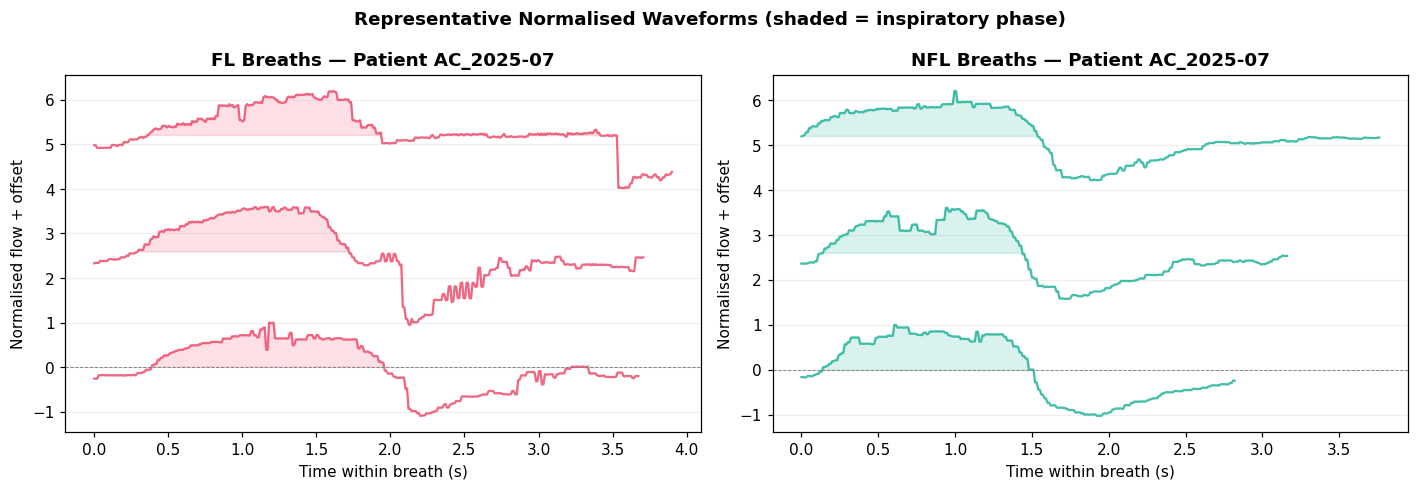

Saved: waveform_examples_v2.png


In [25]:
patients_with_both = (
    features_out.groupby('participant')['target']
    .apply(lambda x: x.nunique() == 2)
)
if not patients_with_both.any():
    print('No patient has both FL and NFL — skipping waveform plot.')
else:
    demo_pid = patients_with_both[patients_with_both].index[0]
    _, demo_signals, _ = next(r for r in all_records if r[2] == demo_pid)
    demo_breaths = features_out[features_out['participant'] == demo_pid]

    fl_examples  = demo_breaths[demo_breaths['target'] == 1].head(3)
    nfl_examples = demo_breaths[demo_breaths['target'] == 0].head(3)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    for ax, examples, color, label in [
        (axes[0], fl_examples,  '#ef5675', 'FL'),
        (axes[1], nfl_examples, '#2eb8a0', 'NFL'),
    ]:
        for offset, (_, brow) in enumerate(examples.iterrows()):
            w = demo_signals[
                (demo_signals['time_s'] >= brow['start_s']) &
                (demo_signals['time_s'] <  brow['end_s'])
            ]
            flow = w['sig_flow'].values.astype(float)
            t    = np.linspace(0, brow['breath_duration'], len(flow))
            pif  = np.max(flow)
            fn   = flow / (pif + 1e-9)   # display normalisation only
            ax.plot(t, fn + offset * 2.6, color=color, lw=1.5, alpha=0.9)
            ax.fill_between(t, offset * 2.6, fn + offset * 2.6,
                            where=flow > 0, color=color, alpha=0.18)

        ax.axhline(0, color='grey', lw=0.6, ls='--')
        ax.set_title(f'{label} Breaths — Patient {demo_pid}', fontweight='bold')
        ax.set_xlabel('Time within breath (s)')
        ax.set_ylabel('Normalised flow + offset')
        ax.grid(axis='y', alpha=0.2)

    plt.suptitle('Representative Normalised Waveforms (shaded = inspiratory phase)',
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig('waveform_examples_v2.png', dpi=110, bbox_inches='tight')
    plt.show()
    print('Saved: waveform_examples_v2.png')